
 EKF PERFORMANCE SUMMARY (7-State 3D Suspension Model)
 Execution time         : 0.3558 ms/step (Req: < 10.0 ms)
 RMSE in s (position)   : 6.1411 m
 RMSE in v_s (speed)    : 0.4065 m/s
 RMSE in e (lateral)    : 0.1212 m
 RMSE in z (vertical)   : 0.0101 m  <-- [Creative Bouncing Estimation]
 Final bias estimate    : 1.4971 m (True value: 1.5)
 Final bias error       : 0.0029 m



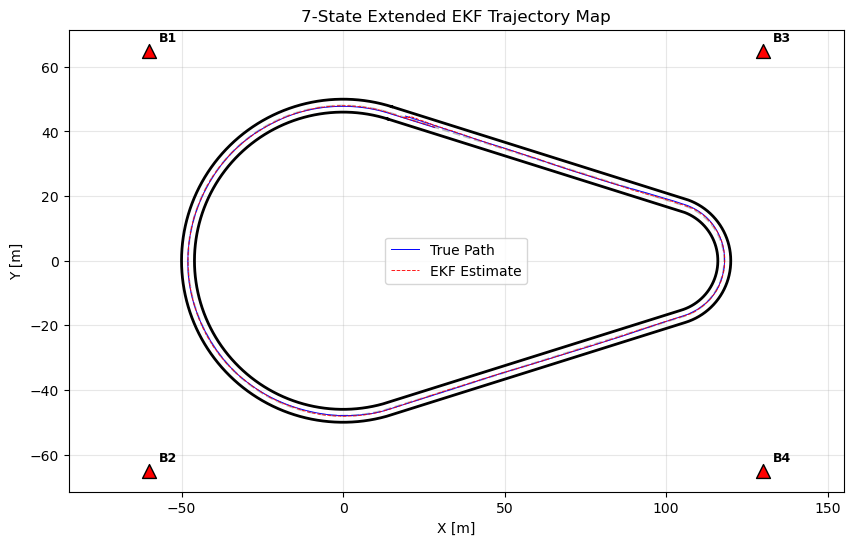

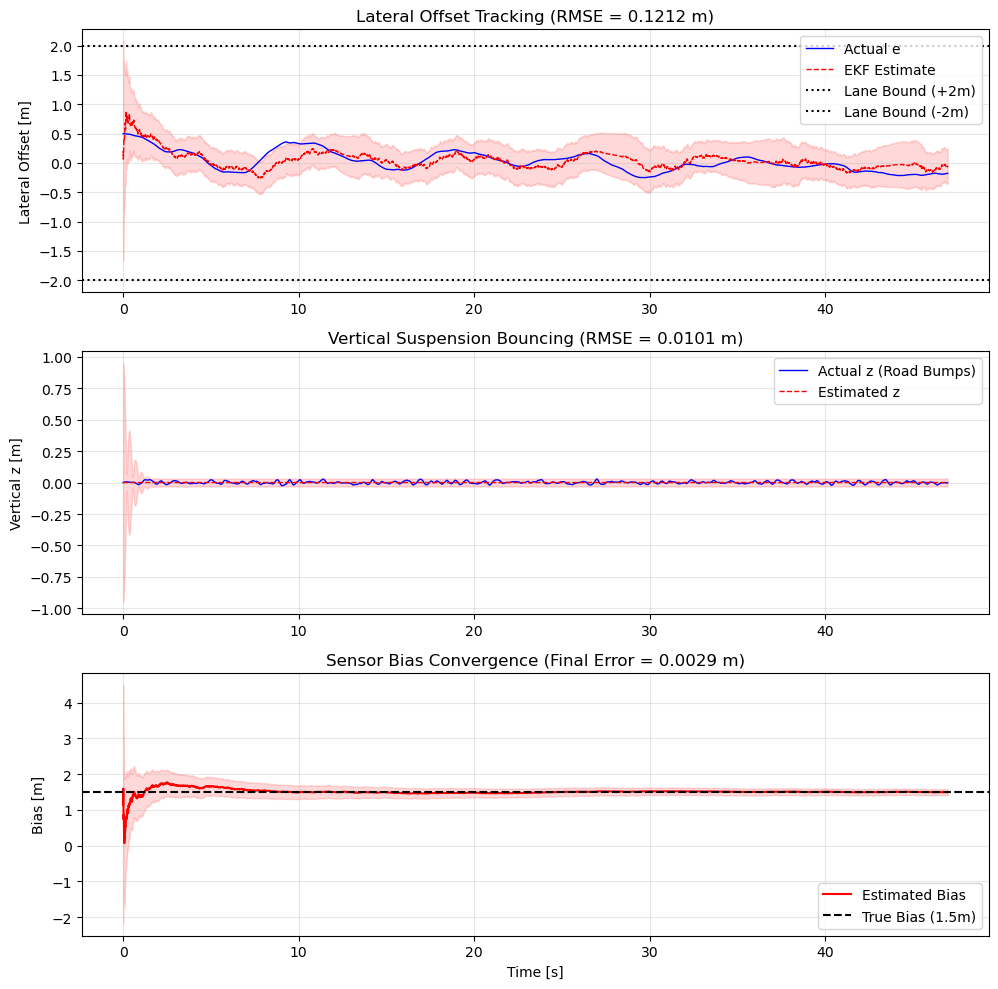

In [8]:
import numpy as np
import casadi as cs
import matplotlib.pyplot as plt
import time

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================
# [Project Information]
# ELE8101 Estimation Project - Step 4 (Creative Extension)
# Dynamics: 7-State EKF with 3D Lateral & Vertical (Bouncing) MSD
# Formulas: Standard EKF (Standard P update & np.linalg.inv)
# States: x = [s, v_s, e, v_e, z, v_z, b]^T
#  - s  : Curvilinear position along centreline [m]
#  - v_s: Longitudinal speed [m/s]
#  - e  : Lateral offset from centreline [m]
#  - v_e: Lateral speed [m/s]
#  - z  : Vertical bouncing displacement [m] (NEW)
#  - v_z: Vertical speed [m/s] (NEW)
#  - b  : Sensor bias on Beacon 1 [m]
# ============================================================

# 1. PARAMETERS & INITIALIZATION
h = 0.01               # Sampling time: 100 Hz
n_sim = 4700           # Simulation duration: 45 seconds
lane_half_width = 2.0  # Total lane width = 4m

# 2. TRACK GEOMETRY (Exact Figure 1 Modelling)
R_left = 48.0
R_right = 18.0
d_centres = 100.0

delta_R = R_left - R_right
phi = np.arccos(delta_R / d_centres)
L_tan = np.sqrt(d_centres**2 - delta_R**2)

L_top = L_tan
L_right = 2.0 * phi * R_right
L_bottom = L_tan
L_left = (2.0 * np.pi - 2.0 * phi) * R_left
track_length = L_top + L_right + L_bottom + L_left

A_centre = np.array([0.0, 0.0])
B_centre = np.array([d_centres, 0.0])
P_LU = A_centre + np.array([R_left * np.cos(phi),  R_left * np.sin(phi)])
P_RU = B_centre + np.array([R_right * np.cos(phi), R_right * np.sin(phi)])
P_LD = A_centre + np.array([R_left * np.cos(phi), -R_left * np.sin(phi)])
P_RD = B_centre + np.array([R_right * np.cos(phi), -R_right * np.sin(phi)])
t_top = (P_RU - P_LU) / np.linalg.norm(P_RU - P_LU)
t_bottom = (P_LD - P_RD) / np.linalg.norm(P_LD - P_RD)

# 3. BEACON SETUP (RE-CENTERED TO [35, 0], Assumed height z=0)
beacons = np.array([
    [-60.0,  65.0],   # B1 (Biased)
    [-60.0, -65.0],   # B2
    [130.0,  65.0],   # B3
    [130.0, -65.0]    # B4
])
ny = len(beacons)
true_bias = 1.5       

# Noise Covariances
R_meas = 1.5**2       
R_mat = R_meas * np.eye(ny)
# Process noise: [w_vs, w_ve, w_vz(3cm roughness), w_b]
Q_mat = np.diag([0.05**2, 0.015**2, 0.03**2, 1e-6**2]) 

# ============================================================
# 4. CASADI SYMBOLIC MODELLING (7-State Expansion)
# ============================================================
nx = 7  # Expanded from 5
nw = 4  # Expanded from 3

x_sym = cs.MX.sym('x', nx) 
w_sym = cs.MX.sym('w', nw) 

s, vs, e, ve, z_pos, vz, b = x_sym[0], x_sym[1], x_sym[2], x_sym[3], x_sym[4], x_sym[5], x_sym[6]

# --- 2D Lateral MSD Constants ---
k_vel = 0.12; v_target = 10.0
k_spring = 0.55; k_damp = 1.05  

# --- 1D Vertical (Bouncing) MSD Constants (User Defined) ---
# f_n = 1.5 Hz  => omega_n = 2*pi*1.5 = 9.4248
# zeta = 0.3
k_spring_z = 88.8   # omega_n^2
k_damp_z = 5.65     # 2 * zeta * omega_n

# --- State Transition Dynamics ---
s_wrapped = s - track_length * cs.floor(s / track_length) 
s_next = s_wrapped + vs * h
vs_next = vs + k_vel * (v_target - vs) * h + w_sym[0]
e_next = e + ve * h
ve_next = ve - (k_spring * e + k_damp * ve) * h + w_sym[1]
# Vertical Bouncing Dynamics
z_next = z_pos + vz * h
vz_next = vz - (k_spring_z * z_pos + k_damp_z * vz) * h + w_sym[2]
b_next = b + w_sym[3] 

x_next = cs.vertcat(s_next, vs_next, e_next, ve_next, z_next, vz_next, b_next)
f_fun = cs.Function('f_fun', [x_sym, w_sym], [x_next])
A_fun = cs.Function('A_fun', [x_sym, w_sym], [cs.jacobian(x_next, x_sym)])

# --- Nonlinear Measurement Model Mapping (3D Geometry) ---
p_top = cs.vertcat(P_LU[0] + (P_RU[0] - P_LU[0])*(s_wrapped/L_top), P_LU[1] + (P_RU[1] - P_LU[1])*(s_wrapped/L_top))
psi_top = float(np.arctan2(t_top[1], t_top[0]))

theta_r = phi - (s_wrapped - L_top) / R_right
p_right = cs.vertcat(B_centre[0] + R_right*cs.cos(theta_r), B_centre[1] + R_right*cs.sin(theta_r))
psi_right = cs.atan2(cs.sin(theta_r), -cs.cos(theta_r))

p_bottom = cs.vertcat(P_RD[0] + (P_LD[0] - P_RD[0])*((s_wrapped-L_top-L_right)/L_bottom), P_RD[1] + (P_LD[1] - P_RD[1])*((s_wrapped-L_top-L_right)/L_bottom))
psi_bottom = float(np.arctan2(t_bottom[1], t_bottom[0]))

theta_l = -phi - (s_wrapped - L_top - L_right - L_bottom) / R_left
p_left = cs.vertcat(A_centre[0] + R_left*cs.cos(theta_l), A_centre[1] + R_left*cs.sin(theta_l))
psi_left = cs.atan2(cs.sin(theta_l), -cs.cos(theta_l))

cond1 = s_wrapped < L_top
cond2 = s_wrapped < (L_top + L_right)
cond3 = s_wrapped < (L_top + L_right + L_bottom)

p_c = cs.if_else(cond1, p_top, cs.if_else(cond2, p_right, cs.if_else(cond3, p_bottom, p_left)))
psi = cs.if_else(cond1, psi_top, cs.if_else(cond2, psi_right, cs.if_else(cond3, psi_bottom, psi_left)))

n_left = cs.vertcat(-cs.sin(psi), cs.cos(psi))
p_vehicle = p_c + e * n_left

h_list = []
for i in range(ny):
    # 3D Euclidean Distance (including z_pos)
    dist = cs.sqrt((p_vehicle[0] - beacons[i, 0])**2 + (p_vehicle[1] - beacons[i, 1])**2 + z_pos**2)
    if i == 0:  
        dist += b
    h_list.append(dist)

h_sym = cs.vertcat(*h_list)
h_fun = cs.Function('h_fun', [x_sym], [h_sym])
H_fun = cs.Function('H_fun', [x_sym], [cs.jacobian(h_sym, x_sym)])

# ============================================================
# 5. EKF LOGIC
# ============================================================

def measurement_update(P_pred, x_pred, y):
    H = np.array(H_fun(x_pred)).astype(float)
    y_pred = np.array(h_fun(x_pred)).astype(float).flatten()
    
    innovation = y - y_pred
    S = H @ P_pred @ H.T + R_mat
    K = P_pred @ H.T @ np.linalg.inv(S)
    
    x_upd = x_pred + K @ innovation.reshape(-1, 1)
    I_KH = np.eye(nx) - K @ H
    P_upd = I_KH @ P_pred
    P_upd = 0.5 * (P_upd + P_upd.T)
    
    return P_upd, x_upd

def time_update(P_upd, x_upd):
    w_zero = np.zeros((nw, 1))
    x_pred = np.array(f_fun(x_upd, w_zero)).astype(float)
    A_val = np.array(A_fun(x_upd, w_zero)).astype(float)
    
    G = np.zeros((nx, nw))
    G[1,0] = 1 # w_vs
    G[3,1] = 1 # w_ve
    G[5,2] = 1 # w_vz
    G[6,3] = 1 # w_b
    
    P_pred = A_val @ P_upd @ A_val.T + G @ Q_mat @ G.T
    return P_pred, x_pred

# ============================================================
# 6. EXPERIMENT EXECUTION
# ============================================================

# [s, vs, e, ve, z, vz, b]
x_true = np.array([[5.0], [10.0], [0.5], [0.0], [0.0], [0.0], [true_bias]])
x_est = np.array([[7.0], [9.5], [0.0], [0.0], [0.0], [0.0], [0.0]])
P_est = np.diag([4.0, 1.0, 0.5, 0.1, 0.1, 0.1, 2.0])

true_hist = np.zeros((n_sim, nx))
est_hist = np.zeros((n_sim, nx))
P_hist = np.zeros((n_sim, nx, nx))

start_time = time.perf_counter()

for t in range(n_sim):
    y_true = np.array(h_fun(x_true)).astype(float).flatten()
    y = y_true + np.random.normal(0.0, np.sqrt(R_meas), ny)
    
    P_est, x_est = measurement_update(P_est, x_est, y)
    true_hist[t, :] = x_true.flatten()
    est_hist[t, :] = x_est.flatten()
    P_hist[t, :, :] = P_est
    P_est, x_est = time_update(P_est, x_est)
    
    # Simulate road roughness (3cm std dev on vertical velocity)
    w_true = np.array([[np.random.normal(0.0, 0.05)], 
                       [np.random.normal(0.0, 0.015)], 
                       [np.random.normal(0.0, 0.03)], 
                       [0.0]])
    x_true = np.array(f_fun(x_true, w_true)).astype(float)
    x_true[6, 0] = true_bias 
    
    # Lateral Hard Boundary
    if abs(x_true[2, 0]) > lane_half_width:
        x_true[2, 0] = np.sign(x_true[2, 0]) * lane_half_width
        x_true[3, 0] *= -0.5

avg_step_time = (time.perf_counter() - start_time) / n_sim

# ============================================================
# 7. METRICS & VISUALIZATION
# ============================================================
t_axis = np.arange(n_sim) * h
burn_in = 100

rmse_s = np.sqrt(np.mean((true_hist[burn_in:, 0] - est_hist[burn_in:, 0])**2))
rmse_vs = np.sqrt(np.mean((true_hist[burn_in:, 1] - est_hist[burn_in:, 1])**2))
rmse_e = np.sqrt(np.mean((true_hist[burn_in:, 2] - est_hist[burn_in:, 2])**2))
rmse_ve = np.sqrt(np.mean((true_hist[burn_in:, 3] - est_hist[burn_in:, 3])**2))
rmse_z = np.sqrt(np.mean((true_hist[burn_in:, 4] - est_hist[burn_in:, 4])**2)) # NEW: Vertical RMSE
final_bias_error = abs(true_bias - est_hist[-1, 6])

print("\n============================================================")
print(" EKF PERFORMANCE SUMMARY (7-State 3D Suspension Model)")
print("============================================================")
print(f" Execution time         : {avg_step_time * 1000:.4f} ms/step (Req: < 10.0 ms)")
print(f" RMSE in s (position)   : {rmse_s:.4f} m")
print(f" RMSE in v_s (speed)    : {rmse_vs:.4f} m/s")
print(f" RMSE in e (lateral)    : {rmse_e:.4f} m")
print(f" RMSE in z (vertical)   : {rmse_z:.4f} m  <-- [Creative Bouncing Estimation]")
print(f" Final bias estimate    : {est_hist[-1, 6]:.4f} m (True value: {true_bias})")
print(f" Final bias error       : {final_bias_error:.4f} m")
print("============================================================\n")

def get_pose_num(s):
    s = s % track_length
    if s < L_top:
        tau = s / L_top
        p_c = (1.0 - tau) * P_LU + tau * P_RU
        psi = np.arctan2(t_top[1], t_top[0])
        return p_c, psi
    s -= L_top
    if s < L_right:
        theta = phi - s / R_right
        p_c = B_centre + np.array([R_right * np.cos(theta), R_right * np.sin(theta)])
        psi = np.arctan2(-np.cos(theta), np.sin(theta))
        return p_c, psi
    s -= L_right
    if s < L_bottom:
        tau = s / L_bottom
        p_c = (1.0 - tau) * P_RD + tau * P_LD
        psi = np.arctan2(t_bottom[1], t_bottom[0])
        return p_c, psi
    s -= L_bottom
    theta = -phi - s / R_left
    p_c = A_centre + np.array([R_left * np.cos(theta), R_left * np.sin(theta)])
    psi = np.arctan2(-np.cos(theta), np.sin(theta))
    return p_c, psi

def get_global_pos(s, e):
    p_c, psi = get_pose_num(s)
    n_left = np.array([-np.sin(psi), np.cos(psi)])
    return p_c + e * n_left

# 1. 2D Trajectory Map
plt.figure(figsize=(10, 6))
s_grid = np.linspace(0.0, track_length, 1200)
c_pts = np.array([get_global_pos(sv, 0.0) for sv in s_grid])
inner_pts = np.array([get_global_pos(sv, -lane_half_width) for sv in s_grid])
outer_pts = np.array([get_global_pos(sv, lane_half_width) for sv in s_grid])

plt.plot(outer_pts[:,0], outer_pts[:,1], 'k-', linewidth=2.0)
plt.plot(inner_pts[:,0], inner_pts[:,1], 'k-', linewidth=2.0)
plt.plot(c_pts[:,0], c_pts[:,1], 'gray', linestyle='--', alpha=0.5)

true_xy = np.array([get_global_pos(s, e) for s, e in true_hist[:, [0, 2]]])
est_xy = np.array([get_global_pos(s, e) for s, e in est_hist[:, [0, 2]]])
plt.plot(true_xy[:,0], true_xy[:,1], 'b-', linewidth=0.7, label='True Path')
plt.plot(est_xy[:,0], est_xy[:,1], 'r--', linewidth=0.7, alpha=0.9, label='EKF Estimate')

plt.scatter(beacons[:,0], beacons[:,1], c='red', marker='^', s=100, edgecolors='k')
for i, (bx, by) in enumerate(beacons):
    plt.text(bx+3, by+3, f"B{i+1}", fontsize=9, fontweight='bold')

plt.axis('equal'); plt.grid(True, alpha=0.3); plt.legend(loc='center')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.title(f'7-State Extended EKF Trajectory Map')
plt.show()

# 2. Lateral, Bias, and Vertical Bouncing Plots
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Lateral
sigma_e = np.sqrt(P_hist[:, 2, 2])
axs[0].plot(t_axis, true_hist[:, 2], 'b-', linewidth=1.0, label='Actual e')
axs[0].plot(t_axis, est_hist[:, 2], 'r--', linewidth=1.0, label='EKF Estimate')
axs[0].fill_between(t_axis, est_hist[:, 2]-3*sigma_e, est_hist[:, 2]+3*sigma_e, color='red', alpha=0.15)
axs[0].axhline(lane_half_width, color='k', linestyle=':', linewidth=1.5, label='Lane Bound (+2m)')
axs[0].axhline(-lane_half_width, color='k', linestyle=':', linewidth=1.5, label='Lane Bound (-2m)')
axs[0].set_ylabel('Lateral Offset [m]')
axs[0].set_title(f'Lateral Offset Tracking (RMSE = {rmse_e:.4f} m)')
axs[0].legend(loc='upper right'); axs[0].grid(True, alpha=0.3)

# Vertical Bouncing (NEW)
sigma_z = np.sqrt(P_hist[:, 4, 4])
axs[1].plot(t_axis, true_hist[:, 4], 'b-', linewidth=1.0, label='Actual z (Road Bumps)')
axs[1].plot(t_axis, est_hist[:, 4], 'r--', linewidth=1.0, label='Estimated z')
axs[1].fill_between(t_axis, est_hist[:, 4]-3*sigma_z, est_hist[:, 4]+3*sigma_z, color='red', alpha=0.15)
axs[1].set_ylabel('Vertical z [m]')
axs[1].set_title(f'Vertical Suspension Bouncing (RMSE = {rmse_z:.4f} m)')
axs[1].legend(loc='upper right'); axs[1].grid(True, alpha=0.3)

# Bias
sigma_b = np.sqrt(P_hist[:, 6, 6])
axs[2].plot(t_axis, est_hist[:, 6], 'r-', linewidth=1.5, label='Estimated Bias')
axs[2].axhline(true_bias, color='k', linestyle='--', linewidth=1.5, label='True Bias (1.5m)')
axs[2].fill_between(t_axis, est_hist[:, 6]-3*sigma_b, est_hist[:, 6]+3*sigma_b, color='red', alpha=0.15)
axs[2].set_xlabel('Time [s]')
axs[2].set_ylabel('Bias [m]')
axs[2].set_title(f'Sensor Bias Convergence (Final Error = {final_bias_error:.4f} m)')
axs[2].legend(loc='lower right'); axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()